# Recreate Rubiks Cube env

Create a custom gymnasuim environment representing a rubiks cube. 


Afterwards, create a model to solve it

## Env

In [1]:
# !pip freeze > requirements_5-27.txt
# !pip install -r requirements_5-27.txt


In [2]:
from __future__ import annotations

from typing import Any, Optional

import numpy as np
import gymnasium as gym
from gymnasium import spaces
import matplotlib.pyplot as plt
import random

from pathlib import Path
import torch


import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical
import json
import pandas as pd


In [3]:
class RubiksCube(gym.Env):
    metadata = {
        "render_modes": ["human", "rgb_array", "ansi"],#unused
        "render_fps": 30,#unused
    }

    def __init__(
        self,
        render_mode: Optional[str] = None,
        max_steps: int = 200,
    ):
        super().__init__()

        self.render_mode = render_mode
        self.max_steps = max_steps

        # Example: 4 discrete actions
        self.action_space = spaces.Discrete(12)

        # Example: 1D continuous observation vector of length 5
        self.observation_space = spaces.Box(
            low=0,
            high=5,
            shape=(54*6,),#6 3x3 faces in a 1d array. each of which is one of 6 colors represented as an int 0 to 5
            dtype=np.int8, #color
        )

        self.state = []
        self.step_count = 0
        self.faces_completed = 0
        self.is_completed = False

        # Optional render state
        self.window = None
        self.clock = None
        

    def _get_obs(self) -> np.ndarray:
        colors = np.array([int(p[3]) for p in self.state])
        return np.eye(int(colors.max())+1,dtype=np.float64)[colors].flatten()

    def _get_info(self) -> dict[str, Any]:
        return {
            "step_count": self.step_count,
            "faces_completed":self.faces_completed,
            'n_scramble':self.n_scramble,
            #num correct faces
        }

    def reset(
            self,
            *,
            seed: Optional[int] = None,
            options: Optional[dict[str, Any]] = None,
            n_scramble = 26
            ) -> tuple[np.ndarray, dict[str, Any]]:
        super().reset(seed=seed)
        self.n_scramble = n_scramble
        self.step_count = 0

        # solved initial state
        self.state = self.place_points_on_cube_faces()

        #sort points by face then x,y,z
        split_faces = self.split_into_faces(self.state)
        for face in ['top','bottom','left','right','front','back']: 
            if face == 'top':
                state = self.sort_by_first_three(split_faces[face])
            else:
                state = np.concatenate((state,self.sort_by_first_three(split_faces[face])),axis=0)
        self.state = state
        
        # make random moves n times
        for _ in range(n_scramble):
            self.move(random.randint(0,11))
        
        observation = self._get_obs()
        info = self._get_info()

        if self.render_mode == "human":
            self.render()

        return observation, info

    def step(
        self,
        action: int,
    ) -> tuple[np.ndarray, float, bool, bool, dict[str, Any]]:
        assert self.action_space.contains(action), f"Invalid action: {action}"

        self.step_count += 1
        #take action
        self.move(action)
        
        
        reward,terminated = self._get_reward()

        # ---- Termination logic (task-defined) ----
        # terminated,_ = self._check_cube_completion()
        # ------------------------------------------

        # ---- Truncation logic (outside MDP, e.g. time limit) ----
        truncated = self.step_count >= self.max_steps
        # ---------------------------------------------------------


        #sort points by face then x,y,z
        split_faces = self.split_into_faces(self.state)
        for face in ['top','bottom','left','right','front','back']: 
            if face == 'top':
                state = self.sort_by_first_three(split_faces[face])
            else:
                state = np.concatenate((state,self.sort_by_first_three(split_faces[face])),axis=0)
        self.state = state
        
        observation = self._get_obs()
        info = self._get_info()

        if self.render_mode == "human":
            self.render()

        return observation, reward, terminated, truncated, info
        
    def _check_cube_completion(self):
        faces = ['front','back','left','right','top','bottom']
        is_completed = True
        num_faces_completed = 0
        for face in faces:
            face_pts,_ = self.get_face(self.state,face,exclude_sides=True)
            face_colors = [p[3] for p in face_pts]
            if len(set(face_colors)) == 1:
                num_faces_completed += 1
            if len(set(face_colors))> 1:
                is_completed = False
        self.faces_completed = num_faces_completed
        self.is_completed = is_completed
        return is_completed,num_faces_completed
        
    def _get_reward(self,reward_type='absolute'):
        is_completed,faces_completed = self._check_cube_completion()
        if reward_type == 'absolute':
            #only reward for completing cube
            return is_completed * 1 + -0.1, is_completed
        elif reward_type == 'breadcrumb':
            return is_completed * 1 + faces_completed -0.01, is_completed
        # elif too many steps, large negative

    
            
    def render(self,radius=1.0, sphere_alpha=0.2, point_color='red', point_size=50):
        # def plot_points_on_sphere(points, radius=1.0, sphere_alpha=0.2, point_color='red', point_size=50):
        """
        Plot a list of 3D Cartesian coordinates on a sphere.
    
        Parameters
        ----------
        points : list of tuple[float, float, float]
            List of (x, y, z) coordinates.
        radius : float
            Radius of the sphere.
        sphere_alpha : float
            Transparency of the sphere surface.
        point_color : str
            Color of plotted points.
        point_size : int
            Size of plotted points.
        """
        points = self.state
        fig = plt.figure(figsize=(8, 8))
        ax = fig.add_subplot(111, projection='3d')
    
        # Create sphere surface
        u = np.linspace(0, 2 * np.pi, 100)
        v = np.linspace(0, np.pi, 100)
        x = radius * np.outer(np.cos(u), np.sin(v))
        y = radius * np.outer(np.sin(u), np.sin(v))
        z = radius * np.outer(np.ones(np.size(u)), np.cos(v))
    
        ax.plot_surface(x, y, z, color='lightblue', alpha=sphere_alpha, edgecolor='none')
    
        # Plot input points
        points = np.asarray(points)
        ax.scatter(points[:, 0], points[:, 1], points[:, 2],
                   c=points[:,3],
                   cmap='viridis',
                   s=point_size)
    
        # Keep aspect ratio equal
        ax.set_box_aspect([1, 1, 1])
    
        ax.set_xlabel("X")
        ax.set_ylabel("Y")
        ax.set_zlabel("Z")
        ax.set_title("Points on a Sphere")
    
        plt.show()

    def close(self):
        #undo anything opened from self.render
        plt.close()

    def rotate_point_on_sphere(self,point, axis, direction=1):
        """
        Rotate a 3D point on a sphere by +/- 90 degrees around a given axis.
    
        Parameters
        ----------
        point : tuple or array-like
            The (x, y, z) point to rotate.
        axis : tuple or array-like
            The axis of rotation as a 3D vector.
        direction : int
            +1 for +90 degrees, -1 for -90 degrees.
    
        Returns
        -------
        np.ndarray
            Rotated point as a length-3 array.
        """
        color = point[3]
        point = point[:3]
        p = np.asarray(point, dtype=float)
        k = np.asarray(axis, dtype=float)
    
        if np.linalg.norm(k) == 0:
            raise ValueError("axis must be non-zero")
        if direction not in (+1, -1):
            raise ValueError("direction must be +1 or -1")
    
        k = k / np.linalg.norm(k)
        theta = direction * np.pi / 2  # 90 degrees
    
        # Rodrigues' rotation formula
        p_rot = (
            p * np.cos(theta)
            + np.cross(k, p) * np.sin(theta)
            + k * np.dot(k, p) * (1 - np.cos(theta))
        )
    
        return [p_rot[0],p_rot[1],p_rot[2],color]

    def rotate_points_on_sphere(self,points, axis, direction=1):
        return np.array([self.rotate_point_on_sphere(point=p,axis=axis,direction=direction) for p in points])

    def get_face(self,points,face,exclude_sides=False): 
        face = face.lower()
        cut = 0.25
        if exclude_sides:
            cut+=0.25
        if face == 'top':
            face_points = [p for p in points if p[2]>cut]
            remainder = [p for p in points if not p[2]>cut]
        elif face == 'bottom':
            face_points = [p for p in points if p[2]<-cut]
            remainder = [p for p in points if not p[2]<-cut]
        elif face == 'left':
            face_points = [p for p in points if p[0]<-cut]
            remainder = [p for p in points if not p[0]<-cut]
        elif face == 'right':
            face_points = [p for p in points if p[0]>cut]
            remainder = [p for p in points if not p[0]>cut]
        elif face == 'front':
            face_points = [p for p in points if p[1]<-cut]
            remainder = [p for p in points if not p[1]<-cut]
        elif face == 'back':
            face_points = [p for p in points if p[1]>cut]
            remainder = [p for p in points if not p[1]>cut]
        assert len(face_points) == 9 + (12*(exclude_sides==False))
        assert len(remainder) == 45 - (12*(exclude_sides==False))
            
        return np.array(face_points),np.array(remainder)
        
    def move_face(self,points,face,direction):
        '''
        face: one of the following: top, bottom, left, right, front, back
        direction: -1 or 1
        '''
        face = face.lower()
        if face in ['top','bottom']:
            axis = (0,0,1)
        elif face in ['left','right']:
            axis = (1,0,0)
        elif face in ['front','back']:
            axis = (0,1,0)
        points_sub, remainder = self.get_face(points,face)
        assert len(points_sub) == 21
        points_sub = self.rotate_points_on_sphere(points_sub,axis=axis,direction=direction)
        return np.concatenate((points_sub,remainder))

    def sort_by_first_three(self,arr):
        arr = np.asarray(arr)
        
        if arr.ndim != 2 or arr.shape[1] != 4:
            raise ValueError("arr must have shape (n, 4)")
        
        idx = np.lexsort((arr[:, 2], arr[:, 1], arr[:, 0]))
        return arr[idx]
        
    def split_into_faces(self,arr):
        faces = ['top','bottom','left','right','front','back']
        return {face:self.get_face(arr,face=face,exclude_sides=True)[0] for face in faces}

    def move(self,action):
        '''
        Rotate a row or column of the cube
        '''
        
        action_map = {
            0:['top',1],
            1:['top',-1],
            2:['bottom',1],
            3:['bottom',-1],
            4:['left',1],
            5:['left',-1],
            6:['right',1],
            7:['right',-1],
            8:['front',1],
            9:['front',-1],
            10:['back',1],
            11:['back',-1],
        }
        points=self.state
        
        choice = action_map[action]
        
        #sort by face, then by x,y,z, then concat 
        moved_faces = self.move_face(points=points,face=choice[0],direction=choice[1])
        split_faces = self.split_into_faces(moved_faces)
        for face in ['top','bottom','left','right','front','back']: 
            if face == 'top':
                state = self.sort_by_first_three(split_faces[face])
            else:
                state = np.concatenate((state,self.sort_by_first_three(split_faces[face])),axis=0)
        self.state = state
        
    def place_points_on_cube_faces(self,grid_range=0.5):
        """Place 9 points on each of the 6 cube-like faces of the sphere.
           Use `grid_range` to control how tightly the points are clustered (0.1 to 1.0)."""
    
        points = []
        radius = 1.0
        center = (0,0,0)
        # Grid from -grid_range to grid_range in 3 steps (local coordinates)
        steps = np.linspace(-grid_range, grid_range, 3)
        
        # For each face (x+, x-, y+, y-, z+, z-)
        for face in ['x+', 'x-', 'y+', 'y-', 'z+', 'z-']:
            for a in steps:
                for b in steps:
                    # Get local coordinates on the cube face
                    if face == 'x+':
                        color = 0
                        x, y, z = 1, a, b
                    elif face == 'x-':
                        # color = 7 #i want to do 7 so colors are different enough, but for now i am lazily using these values for onehot as well
                        color = 1
                        x, y, z = -1, a, b
                    elif face == 'y+':
                        color = 2
                        x, y, z = a, 1, b
                    elif face == 'y-':
                        color = 3
                        x, y, z = a, -1, b
                    elif face == 'z+':
                        color = 4
                        x, y, z = a, b, 1
                    elif face == 'z-':
                        color = 5
                        x, y, z = a, b, -1
                    
                    # Normalize to project onto the sphere
                    norm = np.linalg.norm([x, y, z])
                    x_norm = x / norm
                    y_norm = y / norm
                    z_norm = z / norm
                    
                    # Scale by radius and shift to center
                    x_global = radius * x_norm + center[0]
                    y_global = radius * y_norm + center[1]
                    z_global = radius * z_norm + center[2]
                    
                    points.append((x_global, y_global, z_global,color))
        return points        

### Test reward

In [4]:
env = RubiksCube()
env.reset()
print('reward: ',env._get_reward())
env.get_face(env.state,'right',exclude_sides=True)[0]
# env.get_face(env.state,'bottom')[0]


reward:  (-0.1, False)


array([[ 8.16496581e-01,  4.08248290e-01,  4.08248290e-01,
         5.00000000e+00],
       [ 8.16496581e-01, -4.08248290e-01, -4.08248290e-01,
         5.00000000e+00],
       [ 8.16496581e-01,  4.08248290e-01, -4.08248290e-01,
         1.00000000e+00],
       [ 8.16496581e-01, -4.08248290e-01,  4.08248290e-01,
         1.00000000e+00],
       [ 8.94427191e-01,  2.77333912e-32,  4.47213595e-01,
         4.00000000e+00],
       [ 8.94427191e-01,  4.47213595e-01, -1.36919675e-16,
         5.00000000e+00],
       [ 8.94427191e-01, -4.47213595e-01,  8.21518047e-17,
         2.00000000e+00],
       [ 8.94427191e-01,  0.00000000e+00, -4.47213595e-01,
         0.00000000e+00],
       [ 1.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00]])

In [5]:
env = RubiksCube()
env.reset(n_scramble=0)
print('reward: ',env._get_reward())
for action in range(12):
    env.reset(n_scramble=0)
    env.move(action)
    print('reward: ',env._get_reward())


reward:  (0.9, True)
reward:  (-0.1, False)
reward:  (-0.1, False)
reward:  (-0.1, False)
reward:  (-0.1, False)
reward:  (-0.1, False)
reward:  (-0.1, False)
reward:  (-0.1, False)
reward:  (-0.1, False)
reward:  (-0.1, False)
reward:  (-0.1, False)
reward:  (-0.1, False)
reward:  (-0.1, False)


### Test movement

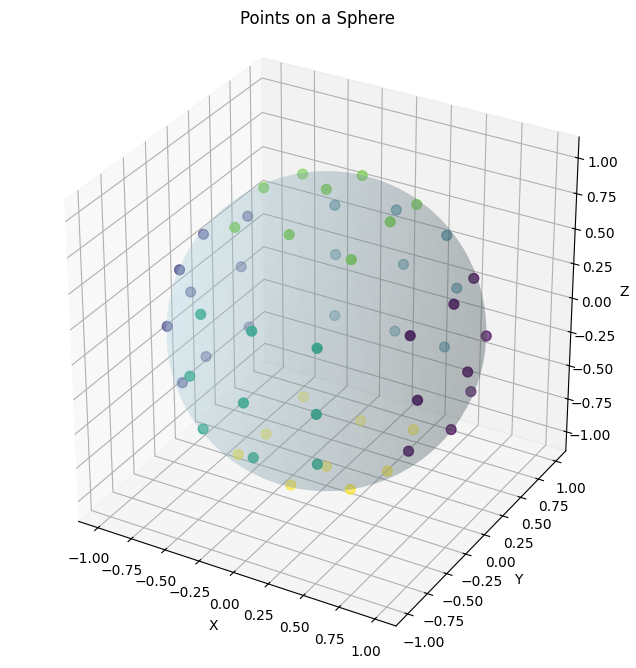

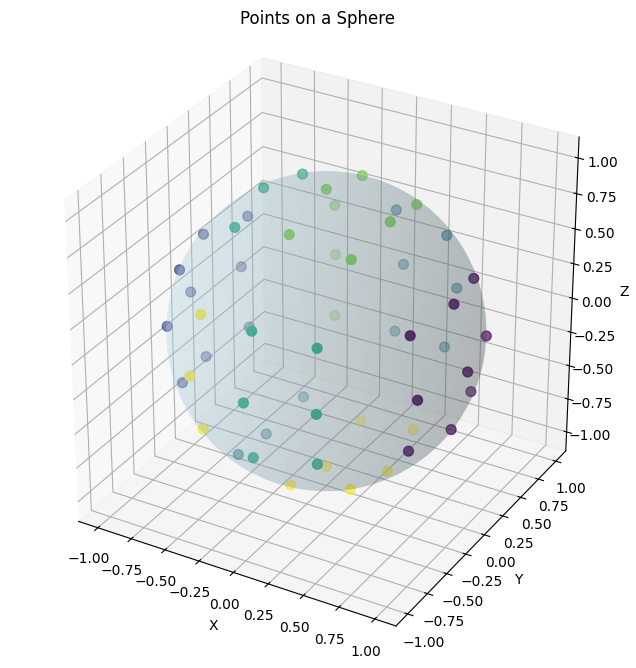

In [6]:
env = RubiksCube()
env.reset(n_scramble=0)
env.render()
env.move(5)
env.render()


### Test observation

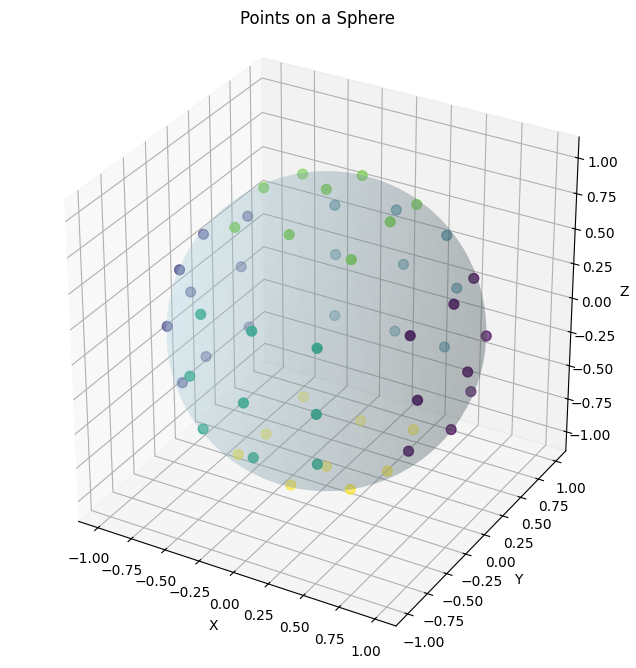

In [7]:
# action_map = {
#             0:['top',1],
#             1:['top',-1],
#             2:['bottom',1],
#             3:['bottom',-1],
#             4:['left',1],
#             5:['left',-1],
#             6:['right',1],
#             7:['right',-1],
#             8:['front',1],
#             9:['front',-1],
#             10:['back',1],
#             11:['back',-1],
        # }
env = RubiksCube()
env.reset(n_scramble=0)

colors_before = [int(p[3]) for p in env.state]
env.move(0)
env.move(1)
env.render()
colors_after = [int(p[3]) for p in env.state]#accidentally recreated 19 mismatch by not sorting the state when moves were commented out
moved_points = [[i,b,a] for i,(b,a) in enumerate(zip(colors_before,colors_after)) if b != a]
assert len(moved_points) == 0


## Model

### Define Model

In [8]:
class RNNPolicy(nn.Module):
    def __init__(self, obs_size, hidden_size, n_actions):
        super().__init__()
        self.input_proj = nn.Linear(obs_size, hidden_size,dtype=torch.float32)
        self.gru = nn.GRU(hidden_size, hidden_size, batch_first=True,num_layers=HIDDEN_LAYERS,dropout=0.1)
        self.policy_head = nn.Linear(hidden_size, n_actions)
        self.value_head = nn.Linear(hidden_size, 1)

    def forward(self, x, h):
        inpt = self.input_proj(x)
        x = torch.tanh(inpt)
        x = x.unsqueeze(1)              # [batch, 1, hidden]
        out, h = self.gru(x, h)         # out: [batch, 1, hidden]
        out = out.squeeze(1)            # [batch, hidden]
        logits = self.policy_head(out)
        value = self.value_head(out).squeeze(-1)
        return logits, value, h

    def init_hidden(self, batch_size=1):
        return torch.zeros(self.gru.num_layers, batch_size, HIDDEN_SIZE, device=DEVICE)

class MLPPolicy(nn.Module):
    def __init__(self, obs_size, hidden_size, n_actions):
        super().__init__()
        self.backbone = nn.Sequential(
            nn.Linear(obs_size, hidden_size, dtype=torch.float32),
            nn.Tanh(),
            nn.Linear(hidden_size, hidden_size, dtype=torch.float32),
            nn.Tanh(),
            # nn.Linear(hidden_size, hidden_size, dtype=torch.float32),
            # nn.Tanh(),
            # nn.Linear(hidden_size, hidden_size, dtype=torch.float32),
            # nn.Tanh(),
            # nn.Linear(hidden_size, hidden_size, dtype=torch.float32),
            # nn.Tanh(),
            # nn.Linear(hidden_size, hidden_size, dtype=torch.float32),
            # nn.Tanh(),
        )
        self.policy_head = nn.Linear(hidden_size, n_actions, dtype=torch.float32)
        self.value_head = nn.Linear(hidden_size, 1, dtype=torch.float32)

    def forward(self, x, h=None):
        x = self.backbone(x)
        logits = self.policy_head(x)
        value = self.value_head(x).squeeze(-1)
        return logits, value, None

    def init_hidden(self, batch_size=1):
        return None

### Train Model

In [9]:
def run_episode(env, model, episode_number, save_dir=None, save_format="csv"):
    """
    Run a single episode and build a pandas DataFrame with one row per step.

    Columns:
      - episode
      - step
      - action
      - reward
      - terminated   (bool from env.step)
      - truncated    (bool from env.step)
      - solved       (bool: terminated & success condition)
      - next_obs_*   (flattened next observation)
    """
    action_hist = np.array([1e-8] * env.action_space.n)
    action_int_hist = []

    obs = env._get_obs() 
    h = model.init_hidden(batch_size=1)

    log_probs = []
    values = []
    rewards = []
    rows = []

    done = False
    total_reward = 0.0
    alpha = 0.01
    step_idx = 0

    while not done:
        obs_t = torch.tensor(obs, dtype=torch.float32, device=DEVICE).unsqueeze(0)
        logits, value, h = model(obs_t, h)

        # penalty = alpha * (action_hist / (action_hist.max() + 1e-8))
        # penalty = torch.from_numpy(penalty).to(logits.device).type_as(logits)
        # logits = logits - penalty

        probs = torch.softmax(logits, dim=-1)
        dist = Categorical(probs)
        action = dist.sample()

        #wilo: we're scrambled before starting this step
        next_obs, reward, terminated, truncated, info = env.step(action.item())
        done = terminated or truncated

        next_obs_arr = np.array(next_obs, copy=True)
        next_obs_flat = next_obs_arr.ravel()

        log_probs.append(dist.log_prob(action))
        values.append(value)
        rewards.append(reward)
        action_hist[action] += 1
        action_int_hist.append(action.item())

        # Define "solved" condition: customize as needed.
        # Example: terminated and positive reward.
        solved = bool(terminated and reward > 5)

        row = {
            "episode": int(episode_number),
            "step": int(step_idx),
            "action": int(action.item()),
            "reward": float(reward),
            "terminated": bool(terminated),
            "truncated": bool(truncated),
            "solved": solved,
        }

        for i, v in enumerate(next_obs_flat):
            row[f"next_obs_{i}"] = float(v)
        rows.append(row)
        obs = next_obs
        total_reward += reward
        step_idx += 1

    df = pd.DataFrame(rows)

    if terminated:
        print(f'episode {episode_number} solved')
    if save_dir is not None and terminated:
        save_path = Path(save_dir).expanduser()
        save_path.mkdir(parents=True, exist_ok=True)

        if save_format == "csv":
            df.to_csv(save_path / f"episode_{episode_number:06d}.csv", index=False)
        elif save_format == "parquet":
            df.to_parquet(save_path / f"episode_{episode_number:06d}.parquet", index=False)
        else:
            raise ValueError(f"Unsupported save_format: {save_format}")

    return log_probs, values, rewards, total_reward, action_hist,action_int_hist, df

def compute_returns(rewards, gamma=0.99):
    returns = []
    R = 0.0
    for r in reversed(rewards):
        R = r + gamma * R # add discounted future rewards to current reward step
        returns.append(R) # log reward
    returns.reverse()
    returns = torch.tensor(returns, dtype=torch.float32, device=DEVICE) #convert to tensor
    if len(returns) != 1:
        returns = (returns - returns.mean()) / (returns.std(unbiased=False) + 1e-8) # normalize
    else:
        returns = returns/(returns+1e-8) #without this, if length is 1, returns is zero 
    return returns
    
def load_or_create_model(model_class, some_path, device="cuda", *model_args, **model_kwargs):
    model = model_class(*model_args, **model_kwargs)
    path = Path(some_path)

    if path.exists():
        state_dict = torch.load(path, map_location=device)
        model.load_state_dict(state_dict)

    model.to(device)
    model.eval()
    return model


#### Pretrain on low-scramble cubes

In [10]:
# reciprocals = {0:1,1:0,2:3,3:2,4:5,5:4,6:7,7:6,8:9,9:8,10:11,11:10}

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
GAMMA = 0.999
LR = 1e-5
HIDDEN_SIZE = 128
HIDDEN_LAYERS = 2
NUM_EPISODES = 10000


env = RubiksCube()
# env = gym.make("CartPole-v1")
obs_size = env.observation_space.shape[0]
n_actions = env.action_space.n

model = MLPPolicy(obs_size, HIDDEN_SIZE, n_actions).to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=LR)
torch.__version__,DEVICE


('2.0.0+cu118', device(type='cuda'))

In [11]:
env.max_steps = 1
num_pretrain_episodes = 12*10000
model = MLPPolicy(obs_size, HIDDEN_SIZE, n_actions).to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=LR)
all_episode_losses = []  # length = num_pretrain_episodes

episodes_per_move = num_pretrain_episodes // n_actions
for it in range(3):
    for move in range(n_actions+1):
        episode_losses = []
    
        for i in range(episodes_per_move):
            # if i % 1000 == 0:
                # print('episode',move*episodes_per_move + i)
            episode_idx = move * episodes_per_move + i  # global episode index
    
            env = RubiksCube()
            env.max_steps = 1
            env.reset(n_scramble=0)
            if move <= 11:
                env.move(move)
    
            log_probs, values, rewards, total_reward, action_history,action_int_hist, df = run_episode(
                env, model, episode_number=episode_idx, save_dir = None
            )
            
            
            # returns = compute_returns(rewards, 0.5)
    
            log_probs = torch.cat(log_probs)
            values = torch.cat(values)
            rewards = torch.tensor(rewards, dtype=torch.float32, device=DEVICE) #convert to tensor
            
            advantages = rewards - values.detach()
            policy_loss = -(log_probs * advantages).sum()
            value_loss = nn.functional.mse_loss(values, rewards)
    
            loss = policy_loss + 0.5 * value_loss
            # loss = policy_loss + 0.001 * value_loss
            # loss = 0.001 * policy_loss + value_loss
    
            # store per‑episode (detach so we keep a float, not a graph)
            all_episode_losses.append(loss.item())
            episode_losses.append(loss)
    
        # batched update for this move
        optimizer.zero_grad()
        batch_loss = torch.stack(episode_losses).mean()
        batch_loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
    
    # torch.save(model.state_dict(), save_path)

plt.figure(figsize=(8, 4))
plt.plot(all_episode_losses, label="Episode loss")
plt.xlabel("Episode")
plt.ylabel("Loss")
plt.title("Policy+Value Loss per Episode")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

episode 14 solved
episode 38 solved
episode 40 solved
episode 46 solved
episode 64 solved
episode 66 solved
episode 69 solved
episode 74 solved
episode 77 solved
episode 87 solved
episode 107 solved
episode 136 solved
episode 137 solved
episode 151 solved
episode 165 solved
episode 171 solved
episode 212 solved
episode 219 solved
episode 226 solved
episode 251 solved
episode 253 solved
episode 265 solved
episode 274 solved
episode 275 solved
episode 289 solved
episode 303 solved
episode 324 solved
episode 327 solved
episode 328 solved
episode 352 solved
episode 358 solved
episode 411 solved
episode 414 solved
episode 426 solved
episode 432 solved
episode 461 solved
episode 474 solved
episode 479 solved
episode 483 solved
episode 489 solved
episode 494 solved
episode 497 solved
episode 505 solved
episode 510 solved
episode 511 solved
episode 513 solved
episode 539 solved
episode 544 solved
episode 565 solved
episode 593 solved
episode 607 solved
episode 611 solved
episode 617 solved
epi

KeyboardInterrupt: 